In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df=pd.read_csv("C:/Users/user/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [103]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [104]:
df.shape

(7043, 21)

In [105]:
print("row:", df.shape[0])
print("column:", df.shape[1])

row: 7043
column: 21


In [106]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [108]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [109]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

You may see 0 missing values for TotalCharges, but that doesn't necessarily mean there are no problematic values.

Why? Because some values in the original dataset are blank strings rather than proper NaN values.

Pandas can treat the blank string as text rather than a missing numerical value.

That's why we're going to investigate TotalCharges separately.

In [110]:
df["TotalCharges"].value_counts().head(10)

         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
Name: TotalCharges, dtype: int64

In [111]:
df["TotalCharges"].dtype

dtype('O')

In [112]:
df["TotalCharges"].str.strip().eq("").sum() # 11 blank values

11

This is important because TotalCharges is supposed to be numerical, but these 11 records contain an empty string.

Why do these blanks exist?

In this dataset, these customers are typically new customers with tenure = 0. Since they have just joined, they don't yet have a recorded total charge.

So we should not simply delete those 11 customers without thinking about it.

In [113]:
df_clean = df.copy()

In [114]:
#Now convert the blank strings into missing values:

df_clean["TotalCharges"] = df_clean["TotalCharges"].replace(" ",pd.NA)

In [115]:
# Then convert the column to numeric:

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

What does errors="coerce" do?

If Pandas encounters something that isn't a valid number, it converts it to NaN rather than causing an error.

In [116]:
df_clean["TotalCharges"].isnull().sum()

11

In [117]:
df_clean[df_clean["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

#You should find that these customers have tenure = 0.

#This is an important business observation:

#These customers are extremely new, so their TotalCharges value is unavailable.

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [118]:
#Before we make that decision, let's complete the data-quality investigation.

#Next, check for duplicate customers:

df_clean["customerID"].duplicated().sum()  #Duplicate customerID

0

In [119]:
df_clean.duplicated().sum() #Duplicate rows

0

### Check the categorical values

In [120]:
df_clean["gender"].value_counts()

Male      3555
Female    3488
Name: gender, dtype: int64

In [121]:
df_clean["SeniorCitizen"].value_counts()

0    5901
1    1142
Name: SeniorCitizen, dtype: int64

In [122]:
df_clean["Partner"].value_counts()

No     3641
Yes    3402
Name: Partner, dtype: int64

In [123]:
df_clean["Dependents"].value_counts()

No     4933
Yes    2110
Name: Dependents, dtype: int64

In [124]:
df_clean["Churn"].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

### Service & Contract Variables

In [125]:
cols = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "Contract", "PaymentMethod"
]

for col in cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts())


--- PhoneService ---
Yes    6361
No      682
Name: PhoneService, dtype: int64

--- MultipleLines ---
No                  3390
Yes                 2971
No phone service     682
Name: MultipleLines, dtype: int64

--- InternetService ---
Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64

--- OnlineSecurity ---
No                     3498
Yes                    2019
No internet service    1526
Name: OnlineSecurity, dtype: int64

--- OnlineBackup ---
No                     3088
Yes                    2429
No internet service    1526
Name: OnlineBackup, dtype: int64

--- DeviceProtection ---
No                     3095
Yes                    2422
No internet service    1526
Name: DeviceProtection, dtype: int64

--- TechSupport ---
No                     3473
Yes                    2044
No internet service    1526
Name: TechSupport, dtype: int64

--- Contract ---
Month-to-month    3875
Two year          1695
One year          1473
Name: Contract,

### Check Numerical Columns

In [126]:
df_clean["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [127]:
df_clean["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [128]:
df_clean["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [129]:
df_clean[["tenure", "MonthlyCharges", "TotalCharges"]].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

In [130]:
""" What we're checking

tenure

Minimum number of months
Maximum number of months
Average customer tenure

MonthlyCharges

Minimum monthly bill
Maximum monthly bill
Average monthly bill

TotalCharges

Minimum total amount
Maximum total amount
Average total amount """

" What we're checking\n\ntenure\n\nMinimum number of months\nMaximum number of months\nAverage customer tenure\n\nMonthlyCharges\n\nMinimum monthly bill\nMaximum monthly bill\nAverage monthly bill\n\nTotalCharges\n\nMinimum total amount\nMaximum total amount\nAverage total amount "

You've basically completed our initial Data Quality Check:

Business Understanding ✅
↓
Column Understanding ✅
↓
Missing-value investigation ✅
↓
Duplicate check ✅
↓
Categorical-value check ✅
↓
Numerical-value check ← we're here
↓
Data Cleaning
↓
EDA 📊

1. Remove the 11 customers with missing TotalCharges

In [131]:
df_clean.shape

(7043, 21)

In [132]:
df_clean = df_clean.dropna(subset=["TotalCharges"])

In [133]:
df_clean.shape

(7032, 21)

2. Verify missing values

In [134]:
df_clean.isnull().sum().sum()

0

3. Check duplicates one final time

In [135]:
df_clean.duplicated().sum()

0

4. Remove customerID — but only now

In [136]:
# Now we're going to remove the identifier because it isn't useful for predicting churn.

df_clean = df_clean.drop("customerID", axis=1)

In [137]:
df_clean.shape

(7032, 20)

Conceptually, we've gone from:

7,043 × 21

to:

7,032 × 20

because:

11 records with missing TotalCharges → removed
customerID → removed

And importantly:

We didn't randomly delete data. We investigated the issue first and documented why we made each change.

That's exactly the kind of reasoning you want to be able to explain in an interview.

### Step 5 — Exploratory Data Analysis (EDA)

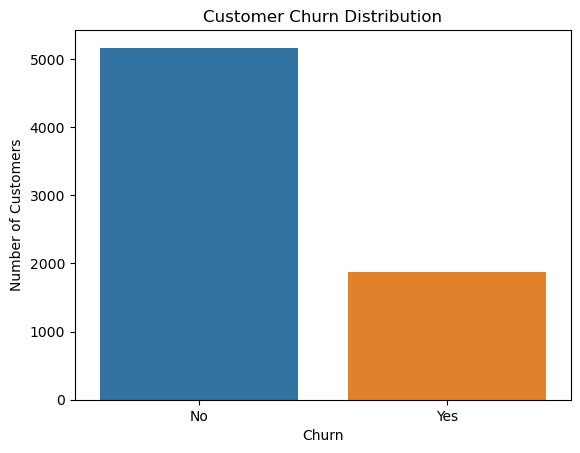

In [138]:
#1 — How many customers churned?

sns.countplot(data=df_clean, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [139]:
#2 — Churn percentage

churn_percentage = df_clean["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

No     73.421502
Yes    26.578498
Name: Churn, dtype: float64


Find our first churn driver

Now we're going to investigate one of the most important variables in this dataset:

## Contract

In [140]:
pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


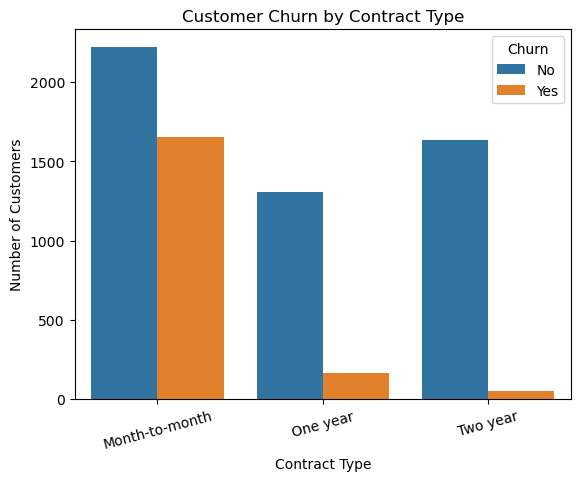

In [141]:
sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()



Customers on month-to-month contracts are much more likely to leave compared with customers on one-year or two-year contracts.

In [142]:
# let's calculate the actual churn rate for each contract type.
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


Interview insight

This is a good statement to eventually use:

"During exploratory data analysis, I found that contract type was strongly associated with customer churn. Month-to-month customers showed substantially higher churn compared with customers on one-year and two-year contracts, suggesting that contract commitment may be an important factor in customer retention."

Notice we're saying "associated with", not "causes."

## Tenure

### tenure = how many months the customer has been with the company.

### Are newer customers more likely to churn than long-term customers?

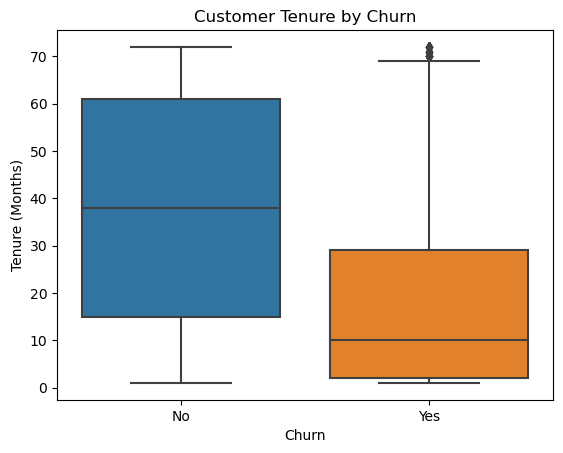

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [143]:
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

df_clean.groupby("Churn")["tenure"].describe()

This suggests that newer customers are at considerably higher churn risk.

The business could therefore focus retention efforts on customers during their early months, rather than waiting until they have already decided to leave.
Median:

10 months vs 38 months

We already have two strong signals:

1. Contract Type

Month-to-month → highest churn

2. Tenure

Shorter-tenure customers → much higher churn tendency

And these two findings may actually be related.

## Monthly Charges

Now let's investigate:

### Do customers paying higher monthly charges churn more?

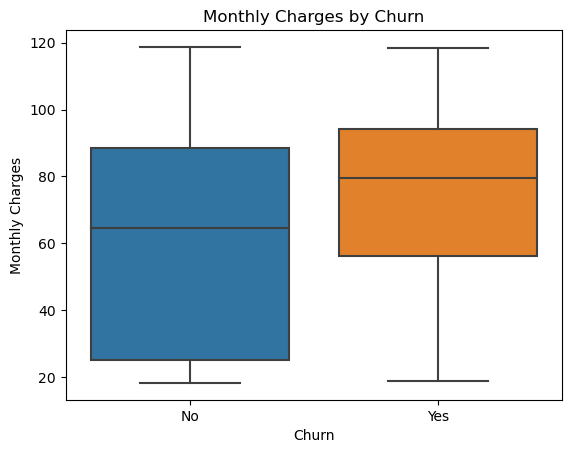

In [144]:
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [145]:
df_clean.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


So the two median values are:

Churn = No → 64.45
Churn = Yes → 79.95

The difference is:

79.95 − 64.45 = 15.50

So the typical churned customer was paying about $15.50 more per month than a customer who stayed.

Business interpretation

### This suggests that higher monthly charges are associated with higher churn.

A possible business explanation is that customers paying more may be more sensitive to pricing or may expect more value from the services they're paying for.

## Internet Service

### let's investigate whether the type of internet service is related to churn.

In [146]:
pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


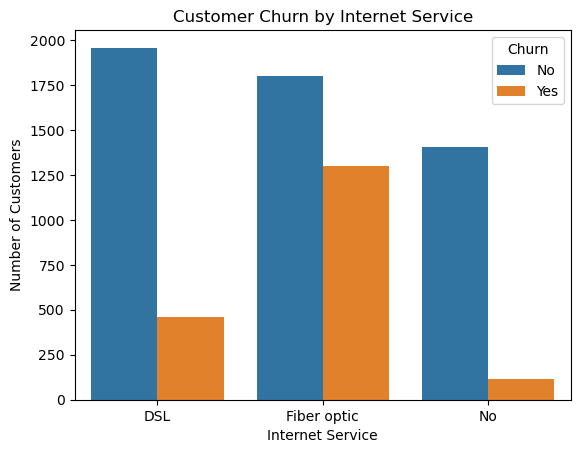

In [147]:
sns.countplot(
    data=df_clean,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

Business interpretation

This suggests that InternetService is strongly associated with customer churn, with fiber-optic customers showing particularly high churn.

And this gives us a great next question:

Why are fiber-optic customers churning at such a high rate?

That's exactly the kind of question a Data Scientist should ask.

🔴 Higher churn

Month-to-month contract

⬇️

Shorter tenure

⬇️

Higher monthly charges

⬇️

Fiber-optic customers


These factors may overlap.

For example, perhaps many fiber-optic customers are also on month-to-month contracts and paying higher monthly charges.

## Payment Method

#### Let's investigate another business-relevant variable:

In [148]:
payment_churn = pd.crosstab(
    df_clean["PaymentMethod"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


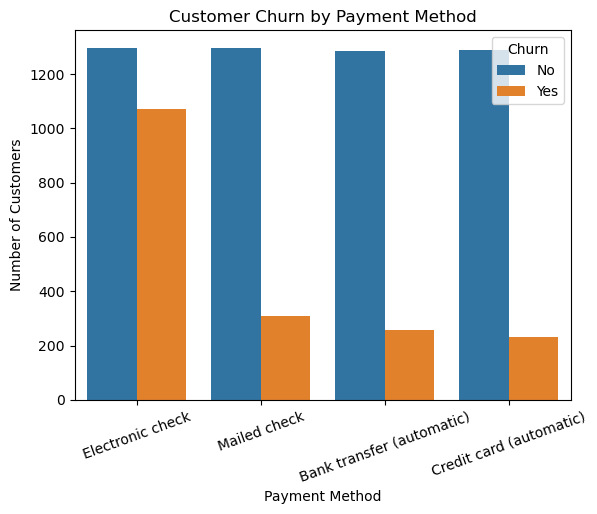

In [149]:
sns.countplot(
    data=df_clean,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

Electronic check has a churn rate of 45.29%, which is the highest among all payment methods.

Business interpretation

This tells us that PaymentMethod is strongly associated with churn.

A company could investigate electronic-check customers more closely and consider:

Encouraging automatic payment methods.

Offering incentives for switching payment methods.

Checking whether electronic-check customers have different contract types.

Investigating whether this group has higher monthly charges.

Understanding whether payment friction contributes to churn.


### Online Security & Tech Support
#### Now I want to investigate whether additional support services are related to churn.

In [150]:
# OnlineSecurity
pd.crosstab(
    df_clean["OnlineSecurity"],
    df_clean["Churn"],
    normalize="index"
) * 100


Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


Customers without Online Security have a 41.78% churn rate, while customers with Online Security have only 14.64% churn.

That's a huge difference — almost 3 times higher.

Business Interpretation

This suggests that customers who subscribe to Online Security are much more likely to stay with the company.

Possible business reasons:

Customers using additional services are more engaged.

They receive more value from the company.

They may find it harder to switch providers.

Interview-ready insight: "Customers without Online Security showed a significantly higher churn rate (41.8%) compared with customers who had the service (14.6%), indicating that value-added services are strongly associated with customer retention."

In [151]:
# TechSupport
pd.crosstab(
    df_clean["TechSupport"],
    df_clean["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


Customers without Tech Support have a 41.65% churn rate, compared with only 15.20% for customers who have Tech Support.

This tells us that technical support is also strongly associated with customer retention.

Business Interpretation

Customers who receive technical support may:

Resolve issues more quickly.

Have a better overall customer experience.

Be less likely to switch to competitors.

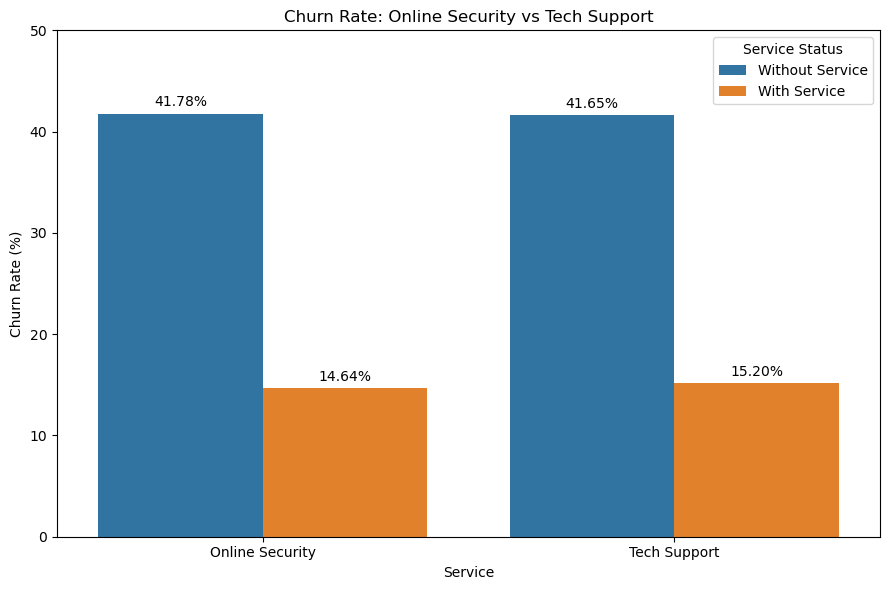

In [152]:
# Calculate churn rates
online_security = pd.crosstab(
    df_clean["OnlineSecurity"],
    df_clean["Churn"],
    normalize="index"
) * 100

tech_support = pd.crosstab(
    df_clean["TechSupport"],
    df_clean["Churn"],
    normalize="index"
) * 100

# Create comparison DataFrame
comparison = pd.DataFrame({
    "Service": ["Online Security", "Tech Support"],
    "Without Service": [
        online_security.loc["No", "Yes"],
        tech_support.loc["No", "Yes"]
    ],
    "With Service": [
        online_security.loc["Yes", "Yes"],
        tech_support.loc["Yes", "Yes"]
    ]
})

# Convert to long format for visualization
comparison_melted = comparison.melt(
    id_vars="Service",
    var_name="Service Status",
    value_name="Churn Rate"
)

# Plot
plt.figure(figsize=(9, 6))

sns.barplot(
    data=comparison_melted,
    x="Service",
    y="Churn Rate",
    hue="Service Status"
)

plt.title("Churn Rate: Online Security vs Tech Support")
plt.xlabel("Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

# Add percentage labels
for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

#### These are the insights we've discovered from the dataset:

Factor

	

Business Insight




Contract

	

Month-to-month customers have the highest churn.




Tenure

	

Customers with shorter tenure are much more likely to churn.




Monthly Charges

	

Customers with higher monthly charges tend to churn more.




Internet Service

	

Fiber optic customers have the highest churn rate (41.9%).




Payment Method

	

Electronic check customers have the highest churn rate (45.3%).




Online Security

	

Customers without Online Security churn nearly 3× more.




Tech Support

	

Customers without Tech Support churn nearly 3× more.

### Top 5 Churn Drivers (Visual Analysis)

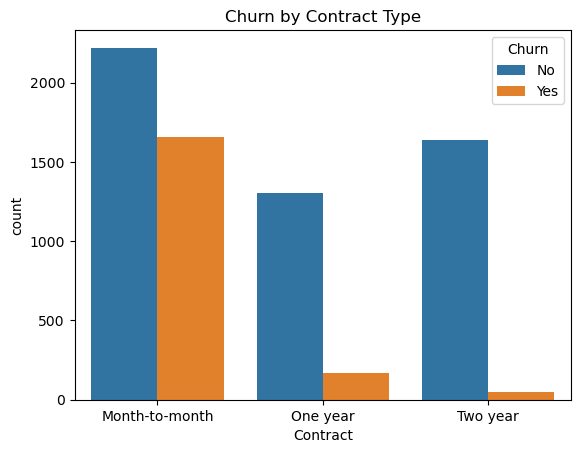

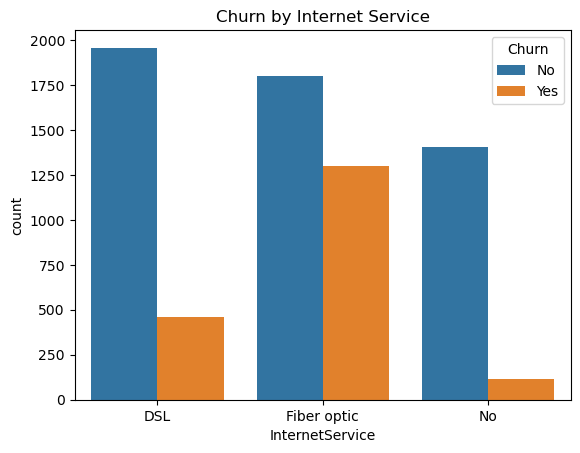

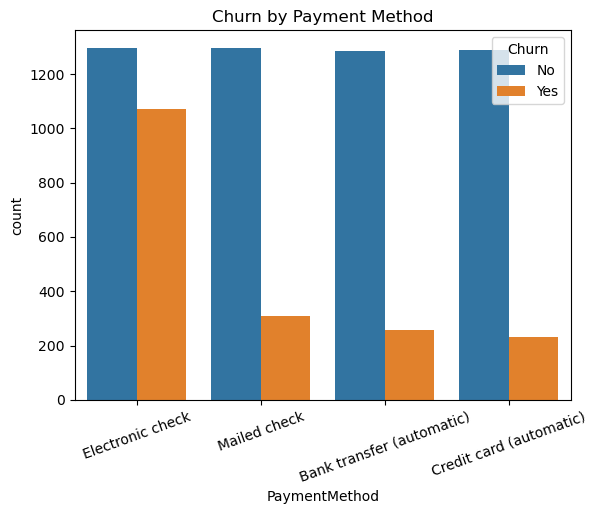

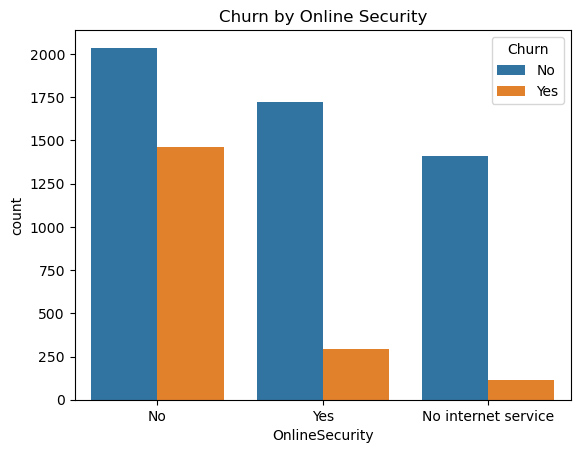

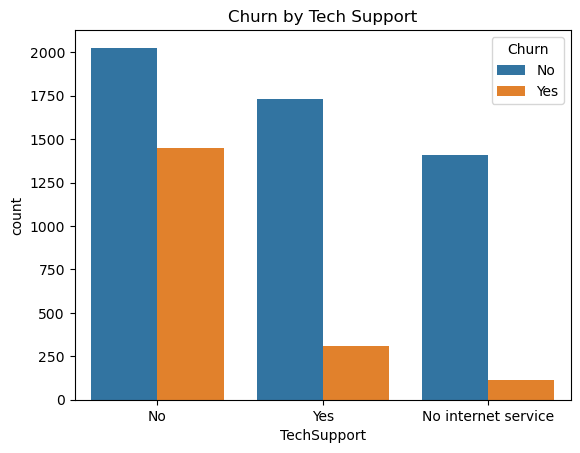

In [153]:
# 1. Churn by Contract
sns.countplot(data=df_clean, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()


# 2. Churn by Internet Service
sns.countplot(data=df_clean, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

# 3. Churn by Payment Method
sns.countplot(data=df_clean, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=20)
plt.title("Churn by Payment Method")
plt.show()

# 4. Churn by Online Security
sns.countplot(data=df_clean, x="OnlineSecurity", hue="Churn")
plt.title("Churn by Online Security")
plt.show()

# 5. Churn by Tech Support
sns.countplot(data=df_clean, x="TechSupport", hue="Churn")
plt.title("Churn by Tech Support")
plt.show()

### Advanced EDA section of your Customer Churn Prediction project.

### Senior Citizen vs Churn
#### Do Senior Citizens churn more than non-Senior Citizens?

In [154]:
senior_churn = pd.crosstab(
    df_clean['SeniorCitizen'],
    df_clean['Churn'],
    normalize='index'
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


So Senior Citizens have a much higher churn rate.

The difference is:

41.68% − 23.61% = 18.07 percentage points


Senior citizens show a substantially higher churn rate than non-senior customers. Approximately 41.68% of senior citizens churn compared with 23.61% of non-senior customers, indicating that senior customers may require targeted retention strategies.

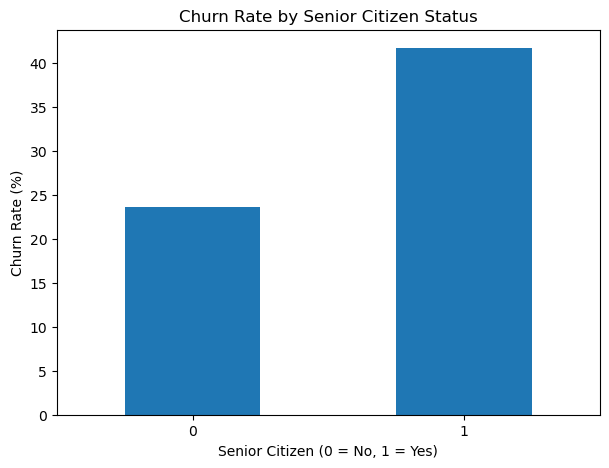

In [155]:
senior_churn = pd.crosstab(
    df_clean['SeniorCitizen'],
    df_clean['Churn'],
    normalize='index'
) * 100

senior_churn['Yes'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

#### Do customers with Partners or Dependents churn less?

In [156]:
pd.crosstab(
    df_clean['Partner'],
    df_clean['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


Customers with partners demonstrate lower churn than customers without partners. The churn rate is 19.66% among customers with partners compared with 32.96% among customers without partners, suggesting that partnered customers may have stronger retention behavior.

32.96% − 19.66% = 13.30 percentage points

#### Do customers with dependents also have lower churn?

In [157]:
pd.crosstab(
    df_clean['Dependents'],
    df_clean['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


Customers with dependents demonstrate significantly lower churn than customers without dependents. The churn rate is 15.45% among customers with dependents compared with 31.27% among customers without dependents, indicating that customers with dependents are associated with stronger retention.

31.27% − 15.45% = 15.82 percentage points

# The really interesting analysis

Now we're going to investigate:

#### Does Fiber Optic + Month-to-Month create a high-risk customer?

#### This is much more powerful because we're going to combine two variables:

### InternetService + Contract vs Churn

In [158]:
contract_internet_churn = pd.crosstab(
    [df_clean['InternetService'], df_clean['Contract']],
    df_clean['Churn'],
    normalize='index'
) * 100

contract_internet_churn

Churn                                  No        Yes
InternetService Contract                            
DSL             Month-to-month  67.784137  32.215863
                One year        90.701754   9.298246
                Two year        98.073836   1.926164
Fiber optic     Month-to-month  45.394737  54.605263
                One year        80.705009  19.294991
                Two year        92.773893   7.226107
No              Month-to-month  81.106870  18.893130
                One year        97.520661   2.479339
                Two year        99.210111   0.789889

Fiber optic + Month-to-month = 54.61% churn

Fiber-optic customers on month-to-month contracts have exceptionally high churn compared with customers using the same service on longer-term contracts.

The combination of Fiber Optic internet service and a month-to-month contract represents a particularly high-risk customer segment, with a churn rate of approximately 54.61%. In contrast, Fiber Optic customers on one-year and two-year contracts show substantially lower churn rates of 19.29% and 7.23%, respectively. This suggests that contract commitment is an important factor in retaining high-risk Fiber Optic customers.

# Next Stage: Feature Engineering

### Tenure vs Churn

In [159]:
df_clean['TenureGroup'] = pd.cut(
    df_clean['tenure'],
    bins=[-1, 12, 24, 48, float('inf')],
    labels=['New Customer', 'Early Stage', 'Established', 'Long-Term']
)

In [160]:
df_clean['TenureGroup'].value_counts()

Long-Term       2239
New Customer    2175
Established     1594
Early Stage     1024
Name: TenureGroup, dtype: int64

In [161]:
pd.crosstab(df_clean['TenureGroup'], df_clean['Churn'], normalize='index') * 100

Churn,No,Yes
TenureGroup,,
New Customer,52.321839,47.678161
Early Stage,71.289062,28.710938
Established,79.611041,20.388959
Long-Term,90.486824,9.513176


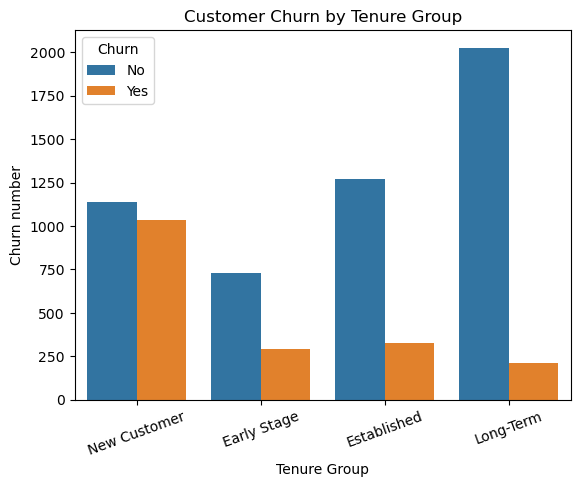

In [162]:
sns.countplot(
    data=df_clean,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn number")
plt.xticks(rotation=20)
plt.show()

### TotalServices

In [163]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df_clean['TotalServices'] = (df_clean[service_cols] == 'Yes').sum(axis=1)

In [164]:
df_clean['TotalServices'].value_counts().sort_index()

0    2213
1     966
2    1033
3    1117
4     850
5     569
6     284
Name: TotalServices, dtype: int64

In [165]:
pd.crosstab(
    df_clean['TotalServices'],
    df_clean['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
TotalServices,,
0,78.535924,21.464076
1,54.244306,45.755694
2,64.181994,35.818006
3,72.605192,27.394808
4,77.647059,22.352941
5,87.521968,12.478032
6,94.718310,5.281690


#### Step 2: Customer Charges

Now let's look at three columns:

tenure → how many months the customer has stayed

MonthlyCharges → what the customer pays each month

TotalCharges → total amount charged so far

AvgMonthlySpend = TotalCharges ÷ Tenure

The idea is to estimate the customer's average monthly spending over their relationship with the company.


In [166]:
(df_clean['tenure'] == 0).sum()
#

0

In [167]:
df_clean['AvgMonthlySpend'] = (
    df_clean['TotalCharges'] / df_clean['tenure']
)

In [168]:
df_clean['AvgMonthlySpend'].describe()

count    7032.000000
mean       64.799424
std        30.185891
min        13.775000
25%        36.179891
50%        70.373239
75%        90.179560
max       121.400000
Name: AvgMonthlySpend, dtype: float64

In [169]:
pd.crosstab(
    pd.qcut(df_clean['AvgMonthlySpend'], 4),
    df_clean['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
AvgMonthlySpend,,
"(13.774000000000001, 36.18]",88.794084,11.205916
"(36.18, 70.373]",74.630262,25.369738
"(70.373, 90.18]",63.708760,36.291240
"(90.18, 121.4]",66.552901,33.447099


In [170]:
df_clean.dtypes

gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                 object
TenureGroup         category
TotalServices          int64
AvgMonthlySpend      float64
dtype: object

## Train/Test Split
First we'll split the dataset into training and testing sets.

In [187]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Churn', 'TenureGroup'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [188]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 21), (1407, 21), (5625,), (1407,))

Encode the categorical variables

we'll use One-Hot Encoding.

In [189]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include=['object']).columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

In [190]:
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [191]:
numerical_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'TotalServices', 'AvgMonthlySpend'],
      dtype='object')

#### Encode + transform the data

We already created the preprocessor. Now we need to fit it only on the training data and transform both training and testing data.

In [192]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [193]:
X_train_encoded.shape, X_test_encoded.shape

((5625, 32), (1407, 32))

#### Next step: Encode the target

Our y_train and y_test still contain:

In [194]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

In [195]:
y_train.value_counts()

0    4130
1    1495
Name: Churn, dtype: int64

In [196]:
y_test.value_counts()

0    1033
1     374
Name: Churn, dtype: int64

In [197]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_encoded, y_train)

LogisticRegression(max_iter=1000)

### Next: Make predictions

In [198]:
y_pred = model.predict(X_test_encoded)

In [199]:
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0], dtype=int64)

### Step: Model Evaluation

In [200]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8017057569296375

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.65      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407


Confusion Matrix:
[[924 109]
 [170 204]]


The next professional step is to check the model's ROC-AUC score.

Why?

Because Logistic Regression gives us probabilities, and ROC-AUC tells us how well the model can separate churners from non-churners across different classification thresholds.

In [201]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_encoded)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8363897790040948


What does ROC-AUC = 0.836 mean?

An ROC-AUC of 0.836 means the model has good ability to distinguish churners from non-churners.

### Next Step: Improve the Model

Next, we'll try a second model:

Random Forest

Why?

Because it can capture non-linear relationships and interactions that Logistic Regression may miss.

We'll compare:

Logistic Regression vs Random Forest

using the same test set and metrics.

In [202]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [203]:
rf_pred = rf_model.predict(X_test_encoded)

In [204]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

rf_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.7874911158493249

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
[[922 111]
 [188 186]]

ROC-AUC: 0.8189156239808253


In [205]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.30, 0.61, 0.05)

for threshold in thresholds:
    pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(
        "Threshold:", round(threshold, 2),
        "| Precision:", round(precision, 2),
        "| Recall:", round(recall, 2),
        "| F1:", round(f1, 2)
    )

Threshold: 0.3 | Precision: 0.52 | Recall: 0.74 | F1: 0.61
Threshold: 0.35 | Precision: 0.55 | Recall: 0.7 | F1: 0.62
Threshold: 0.4 | Precision: 0.59 | Recall: 0.68 | F1: 0.63
Threshold: 0.45 | Precision: 0.62 | Recall: 0.64 | F1: 0.63
Threshold: 0.5 | Precision: 0.65 | Recall: 0.55 | F1: 0.59
Threshold: 0.55 | Precision: 0.66 | Recall: 0.47 | F1: 0.55
Threshold: 0.6 | Precision: 0.69 | Recall: 0.37 | F1: 0.48


In [206]:
final_threshold = 0.40

final_pred = (y_prob >= final_threshold).astype(int)

print("Final Classification Report:")
print(classification_report(y_test, final_pred))

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1033
           1       0.59      0.68      0.63       374

    accuracy                           0.79      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.79      0.79      1407


Final Confusion Matrix:
[[855 178]
 [121 253]]


In [207]:
feature_names = preprocessor.get_feature_names_out()

coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['AbsCoefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'AbsCoefficient',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,AbsCoefficient
9,cat__OnlineSecurity_Yes,-0.426050,0.426050
21,cat__Contract_Two year,-0.424287,0.424287
3,cat__PhoneService_Yes,-0.422217,0.422217
15,cat__TechSupport_Yes,-0.390905,0.390905
24,cat__PaymentMethod_Electronic check,0.388629,0.388629
22,cat__PaperlessBilling_Yes,0.356893,0.356893
6,cat__InternetService_Fiber optic,0.334812,0.334812
20,cat__Contract_One year,-0.331523,0.331523
17,cat__StreamingTV_Yes,0.327892,0.327892
19,cat__StreamingMovies_Yes,0.303933,0.303933


## Final Business Insights & Conclusion

### Key Business Insights

The analysis identified several customer characteristics associated with higher churn:

- **Month-to-month contract customers** showed substantially higher churn than customers on one-year or two-year contracts.
- **Electronic check** customers had the highest churn rate among payment methods.
- Customers without **Online Security** and **Tech Support** showed considerably higher churn.
- **Fiber-optic internet** customers showed relatively higher churn.
- Customers with **shorter tenure** were more likely to churn.
- Customers with fewer additional services generally showed higher churn.
- The combination of **Fiber Optic + Month-to-Month contract** represented a particularly high-risk segment.

### Final Model

Logistic Regression was selected as the final model because it achieved better overall performance than Random Forest, with **80.17% accuracy** and **0.8364 ROC-AUC**.

The classification threshold was then reduced from **0.50 to 0.40** to improve the identification of potential churn customers. This increased churn recall from **55% to 68%** and improved the churn F1-score from **59% to 63%**, while maintaining approximately **79% overall accuracy**.

### Conclusion

This project demonstrates an end-to-end customer churn prediction workflow covering data cleaning, exploratory data analysis, feature engineering, preprocessing, model development, model comparison, and threshold optimization.

The final model can support targeted customer-retention efforts by helping the business identify customers who are more likely to churn.
